# Part B – Supervised Text Classification (Random Forest Model)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Random Forest Classifier with TF-IDF features


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Download required NLTK data
nltk.download('stopwords', quiet=True)


True

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Ensure 'IMDB Dataset.csv' is in the same directory as this notebook
df = pd.read_csv('IMDB Dataset.csv')

# Encode label: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(3)


Dataset shape  : (49582, 3)

Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [4]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Lowercase and tokenise
    tokens = text.lower().split()
    # 4 & 5. Remove stop words and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning to all reviews (this may take ~1-2 minutes)
print("Cleaning reviews... please wait.")
df['clean_review'] = df['review'].apply(clean_text)
print(f"Done. Sample cleaned review:\n\n{df['clean_review'].iloc[0][:300]}")


Cleaning reviews... please wait.
Done. Sample cleaned review:

one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e


In [5]:
# ── Train/Test Split & TF-IDF Vectorisation ───────────────────────────────────
X = df['clean_review']
y = df['label']

# 80/20 stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: convert text to numerical feature matrix
# max_features=40000 adjusted for cleaned dataset size
# ngram_range=(1,2) includes unigrams and bigrams
# Note: max_features is reduced for Random Forest to manage training time
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on training data only
X_test_tfidf  = tfidf.transform(X_test)         # transform test data

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")


Training samples : 39665
Test samples     : 9917
TF-IDF features  : 10000


In [6]:
# ── Build & Train Random Forest Model ────────────────────────────────────────
# RandomForestClassifier is an ensemble method that builds multiple decision
# trees and combines their predictions through majority voting.
# n_estimators: number of trees in the forest
# n_jobs=-1: uses all available CPU cores for faster training
# random_state=42: ensures reproducibility

rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest model... please wait.")
rf_model.fit(X_train_tfidf, y_train)
print("Random Forest model trained successfully.")


Training Random Forest model... please wait.
Random Forest model trained successfully.


In [7]:
# ── Model Evaluation ──────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test_tfidf)

# Compute evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("     RANDOM FOREST MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


     RANDOM FOREST MODEL EVALUATION RESULTS
  Accuracy  : 0.8528  (85.28%)
  Precision : 0.8501
  Recall    : 0.8579
  F1-Score  : 0.8540

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      4940
    Positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



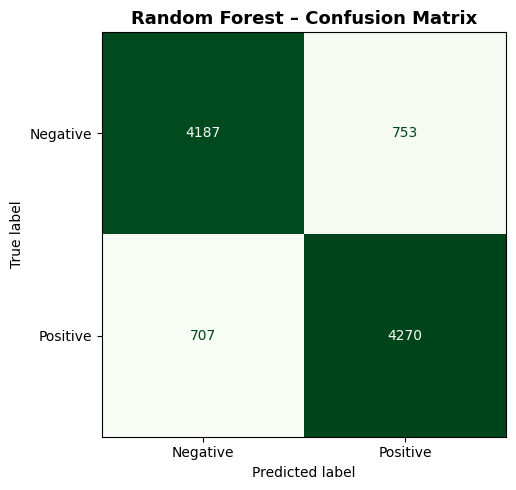

In [8]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest – Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


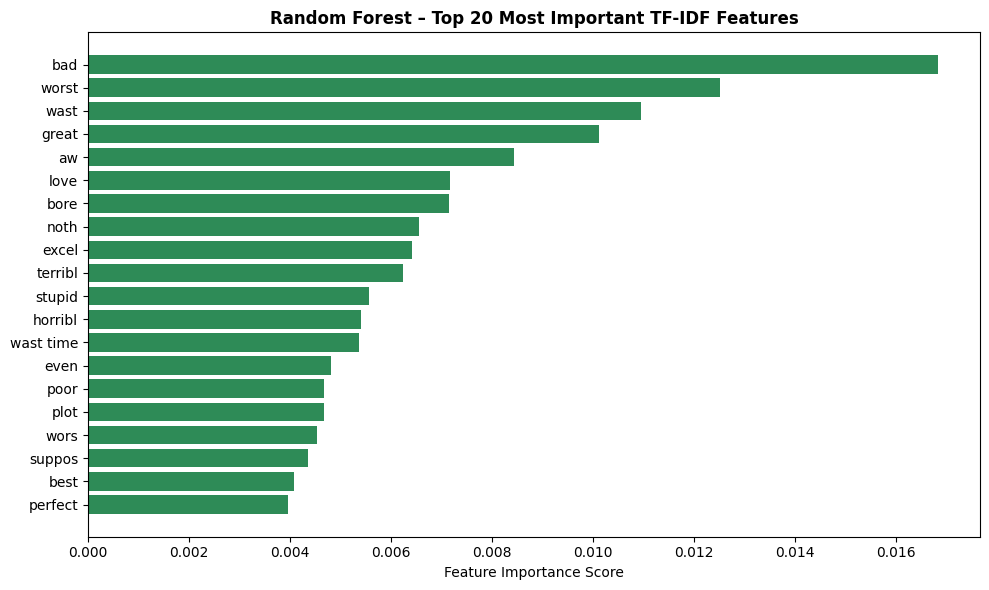

In [9]:
# ── Top Feature Importances ───────────────────────────────────────────────────
# Random Forest provides a feature_importances_ attribute which reflects
# how much each TF-IDF feature contributed to reducing impurity across all trees.
# Higher importance = more useful for classification.

feature_names  = tfidf.get_feature_names_out()
importances    = rf_model.feature_importances_

top_n      = 20
top_idx    = importances.argsort()[-top_n:][::-1]
top_words  = [feature_names[i] for i in top_idx]
top_scores = [importances[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_words[::-1], top_scores[::-1], color='seagreen')
ax.set_title('Random Forest – Top 20 Most Important TF-IDF Features', fontweight='bold', fontsize=12)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()


---
# Part B – Q3: Hyperparameter Tuning (Random Forest)

GridSearchCV is used to systematically search over a defined parameter grid.  
5-fold cross-validation is applied on the training set for each combination.


In [10]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 20, 50],
    'min_samples_split': [2, 5]
}

# Initialise base estimator
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV with 5-fold cross-validation, scoring on F1 macro
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV over the following grid:")
print(param_grid)
print("\nThis may take several minutes...\n")

grid_search.fit(X_train_tfidf, y_train)

print("\nGridSearchCV complete.")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Running GridSearchCV over the following grid:
{'n_estimators': [100, 200], 'max_depth': [None, 20, 50], 'min_samples_split': [2, 5]}

This may take several minutes...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV complete.
Best Parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.8571


In [11]:
# ── Evaluate Best Tuned Random Forest on Test Set ─────────────────────────────
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_tfidf)

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print("=" * 55)
print("     TUNED RANDOM FOREST MODEL EVALUATION RESULTS")
print("=" * 55)
print(f"  Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print("=" * 55)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))


     TUNED RANDOM FOREST MODEL EVALUATION RESULTS
  Accuracy  : 0.8588  (85.88%)
  Precision : 0.8519
  Recall    : 0.8700
  F1-Score  : 0.8608

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4940
    Positive       0.85      0.87      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



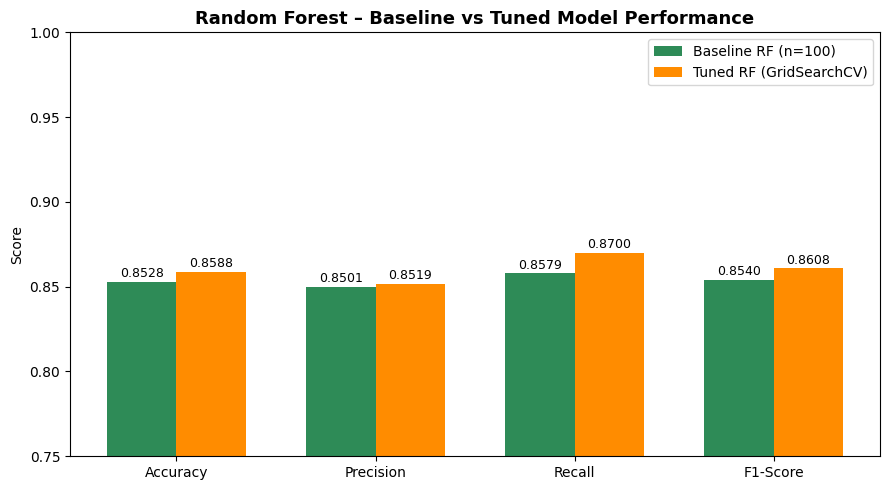

In [12]:
# ── Before vs After Tuning Comparison ────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc,   precision, recall, f1]
tuned_vals    = [acc_t, prec_t,    rec_t,  f1_t]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline RF (n=100)', color='seagreen')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned RF (GridSearchCV)', color='darkorange')

ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.set_title('Random Forest – Baseline vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Annotate bars with exact values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
